# Toy Monte Carlo

Να δημιουργήσετε κώδικα Monte Carlo για τη διάταξη δυο παραλλήλων πλακών, με χαρακτηριστικά:
- Διαστάσεις "πλακών/ηλεκτροδίων" : $10 \times 10 \mathrm{~cm}^{2}$.
- Γεωμετρία: Τα κέντρα των δύο επιπέδων ευθυγραμμίζονται στον άξονα z.
- Απόσταση (d): Μεταβλητή από 2 mm έως 7 mm .

Από το κέντρο της μιας πλάκας να δημιουργήσετε "τροχιές" προς το απέναντι ηλεκτρόδιο, με ισοτροπική κατανομή των γωνιών στο ημισφάιριο.
α) Να υπολογίσετε την απόσταση/μήκος της κάθε τροχιάς, που βρίσκεται εντός του νοητού τρισδιάστατου παραλληλεπιπέδου που σχηματίζουν οι δύο πλάκες και να κάνετε το ιστόγραμμα κατανομής.
β) Αντί σημειακής "πηγής", δημιουργήσετε κυκλική περιοχή ακτίνας 2 cm με το ίδιο κέντρο. Οι συντεταγμένες "γέννησης" των σημείων να ακολουθούν κανονική κατανομή εντός του κύκλου και υπολογίσετε το (α).
γ) Μεταφέρετε το κέντρο της πηγής στην μία εκ των γωνιών του ηλεκτροδίου, ώστε όλη η επιφάνεια του κύκλου να παραμένει εντός των ορίων της πλάκας και υπολογίσετε την ίδια κατανομή.
δ) Επαναλάβατε τα (β) και (γ) για d = 2 mm και 7 mm .

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sample_isotropic_hemisphere(N):
    phi = np.random.uniform(0, 2*np.pi, N)
    cos_theta = np.random.uniform(0, 1, N)
    sin_theta = np.sqrt(1 - cos_theta**2)

    dx = sin_theta * np.cos(phi)
    dy = sin_theta * np.sin(phi)
    dz = cos_theta

    return dx, dy, dz

In [3]:
def sample_point_source(N, center=(0,0)):
    x0 = np.full(N, center[0])
    y0 = np.full(N, center[1])
    return x0, y0

In [4]:
def sample_circular_source(N, R, center=(0,0)):
    r = R * np.sqrt(np.random.uniform(0,1,N))
    theta = np.random.uniform(0, 2*np.pi, N)

    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)

    return x, y

def sample_circular_source_gaussian(N, R, center=(0,0)):
    x_out = []
    y_out = []

    while len(x_out) < N:
        x = np.random.normal(center[0], R/2, N)
        y = np.random.normal(center[1], R/2, N)

        mask = (x - center[0])**2 + (y - center[1])**2 <= R**2

        x_out.extend(x[mask])
        y_out.extend(y[mask])

    return np.array(x_out[:N]), np.array(y_out[:N])

In [5]:
def compute_track_lengths(x0, y0, dx, dy, dz, plate_size, d):
    half = plate_size / 2

    # intersection with top plate
    t_z = d / dz

    # intersection with x boundaries
    tx1 = (-half - x0) / dx
    tx2 = ( half - x0) / dx
    t_x = np.where(dx != 0, np.minimum(
        np.where(tx1 > 0, tx1, np.inf),
        np.where(tx2 > 0, tx2, np.inf)
    ), np.inf)

    # intersection with y boundaries
    ty1 = (-half - y0) / dy
    ty2 = ( half - y0) / dy
    t_y = np.where(dy != 0, np.minimum(
        np.where(ty1 > 0, ty1, np.inf),
        np.where(ty2 > 0, ty2, np.inf)
    ), np.inf)

    t_exit = np.minimum(t_z, np.minimum(t_x, t_y))

    lengths = t_exit * np.sqrt(dx**2 + dy**2 + dz**2)

    return lengths

In [6]:
def run_simulation(
    N=10000,
    plate_size=0.10,
    d=0.005,
    source_type="point",   # "point" or "circle"
    R=0.02,
    center=(0,0)
):
    
    dx, dy, dz = sample_isotropic_hemisphere(N)
    
    if source_type == "point":
        x0, y0 = sample_point_source(N, center)
    elif source_type == "circle":
        x0, y0 = sample_circular_source_gaussian(N, R, center)
    else:
        raise ValueError("Unknown source_type")
    
    lengths = compute_track_lengths(x0, y0, dx, dy, dz, plate_size, d)
    
    return lengths

In [7]:
def plot_histogram(lengths, title=""):
    plt.figure()
    plt.hist(lengths, bins=60, density=True)
    plt.xlabel("Track length")
    plt.ylabel("Probability density")
    plt.title(title)
    plt.show()

In [8]:
def plot_geometry(plate_size=0.10, d=0.005, source_type="point", R=0.02, center=(0,0)):
    half = plate_size / 2

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    # plates
    X = np.array([[-half, half], [-half, half]])
    Y = np.array([[-half, -half], [half, half]])

    Z1 = np.zeros_like(X)
    Z2 = np.ones_like(X) * d

    ax.plot_surface(X, Y, Z1, alpha=0.3)
    ax.plot_surface(X, Y, Z2, alpha=0.3)

    # source
    if source_type == "point":
        ax.scatter(center[0], center[1], 0)
    else:
        theta = np.linspace(0, 2*np.pi, 100)
        x = center[0] + R*np.cos(theta)
        y = center[1] + R*np.sin(theta)
        z = np.zeros_like(x)
        ax.plot(x, y, z)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    plt.show()

In [9]:
def plot_rays(x0, y0, dx, dy, dz, d, plate_size, n_lines=50,
              source_type="point", R=0.02, center=(0,0)):

    half = plate_size / 2

    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    # --- plates ---
    X = np.array([[-half, half], [-half, half]])
    Y = np.array([[-half, -half], [half, half]])

    Z1 = np.zeros_like(X)
    Z2 = np.ones_like(X) * d

    ax.plot_surface(X, Y, Z1, alpha=0.25)
    ax.plot_surface(X, Y, Z2, alpha=0.25)

    # --- rays ---
    idx = np.random.choice(len(x0), n_lines, replace=False)

    for i in idx:
        t = d / dz[i]  # μέχρι πάνω πλάκα

        x_end = x0[i] + t * dx[i]
        y_end = y0[i] + t * dy[i]
        z_end = d

        ax.plot(
            [x0[i], x_end],
            [y0[i], y_end],
            [0, z_end],
            color="tab:blue",
            alpha=0.7,
            linewidth=1
        )

    # --- source ---
    if source_type == "point":
        ax.scatter(
            center[0], center[1], 0,
            color="black",
            s=60
        )

    elif source_type == "circle":
        theta = np.linspace(0, 2*np.pi, 200)
        x = center[0] + R * np.cos(theta)
        y = center[1] + R * np.sin(theta)
        z = np.zeros_like(x)

        ax.plot(x, y, z, color="black", linewidth=2)

    # --- limits (important for nice geometry) ---
    ax.set_xlim(-half, half)
    ax.set_ylim(-half, half)
    ax.set_zlim(0, d)

    # --- labels ---
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    ax.set_title("Monte Carlo Ray Tracing Between Parallel Plates")

    plt.show()

### (α) Να υπολογίσετε την απόσταση/μήκος της κάθε τροχιάς, που βρίσκεται εντός του νοητού τρισδιάστατου παραλληλεπιπέδου που σχηματίζουν οι δύο πλάκες και να κάνετε το ιστόγραμμα κατανομής.

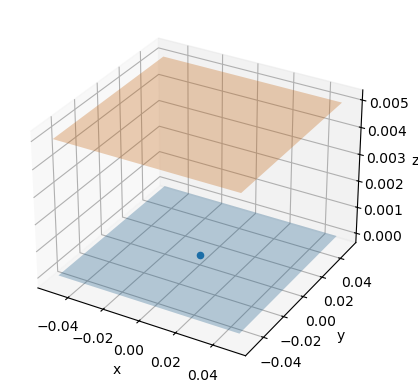

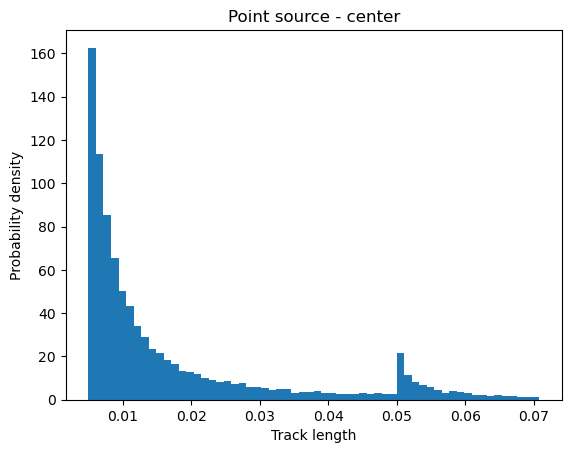

In [10]:
lengths_a = run_simulation(N=20000, d=0.005)
plot_geometry(d=0.005)
plot_histogram(lengths_a, "Point source - center")

### (β) Αντί σημειακής "πηγής", δημιουργήσετε κυκλική περιοχή ακτίνας 2 cm με το ίδιο κέντρο. Οι συντεταγμένες "γέννησης" των σημείων να ακολουθούν κανονική κατανομή εντός του κύκλου και υπολογίσετε το (α).

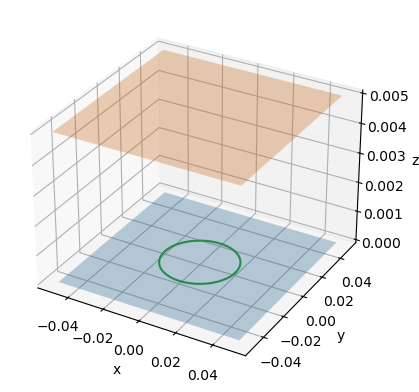

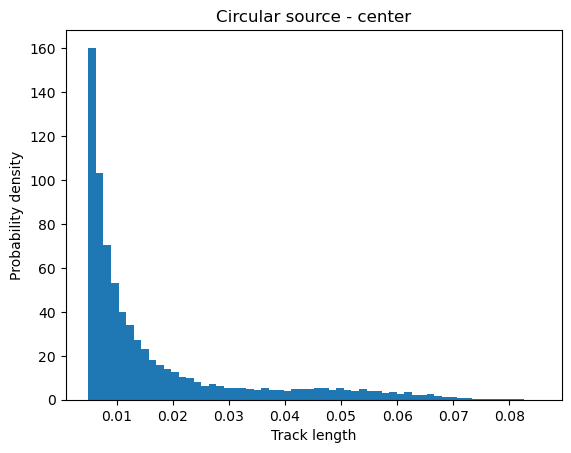

In [11]:
lengths_b = run_simulation(N=20000, d=0.005, source_type="circle", R=0.02)
plot_geometry(d=0.005, source_type="circle", R=0.02)
plot_histogram(lengths_b, "Circular source - center")

### (γ) Μεταφέρετε το κέντρο της πηγής στην μία εκ των γωνιών του ηλεκτροδίου, ώστε όλη η επιφάνεια του κύκλου να παραμένει εντός των ορίων της πλάκας και υπολογίσετε την ίδια κατανομή.

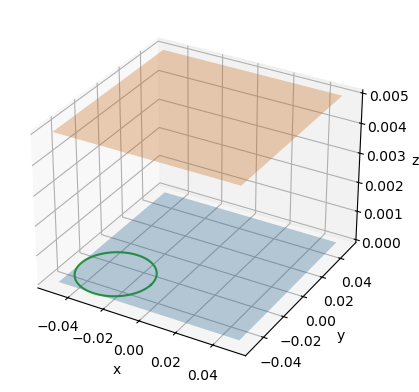

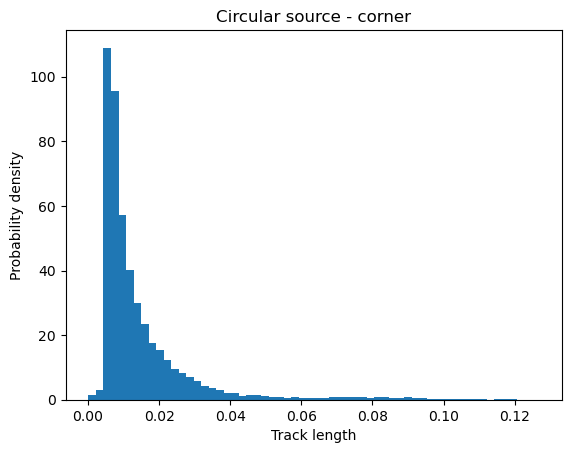

In [12]:
corner = (-0.05 + 0.02, -0.05 + 0.02)

lengths_c = run_simulation(
    N=20000,
    d=0.005,
    source_type="circle",
    R=0.02,
    center=corner
)

plot_geometry(d=0.005, source_type="circle", R=0.02, center=corner)
plot_histogram(lengths_c, "Circular source - corner")

### (δ) Επαναλάβατε τα (β) και (γ) για d = 2 mm και 7 mm .

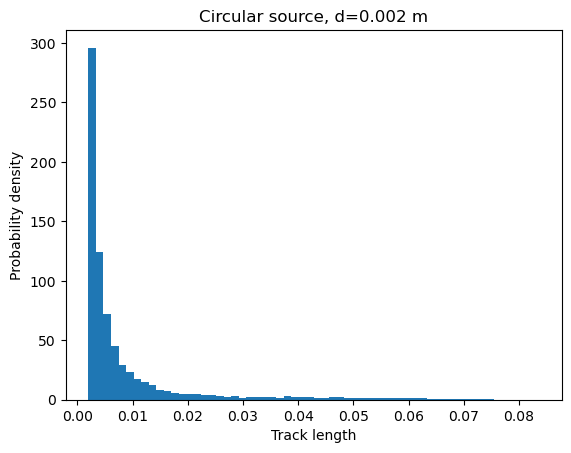

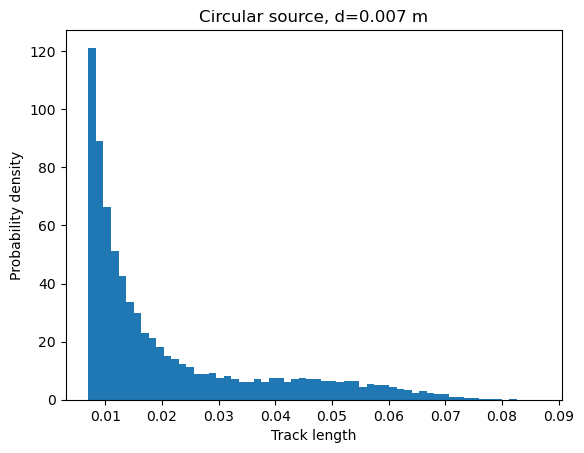

In [13]:
for d in [0.002, 0.007]:
    lengths = run_simulation(
        N=20000,
        d=d,
        source_type="circle",
        R=0.02
    )
    plot_histogram(lengths, f"Circular source, d={d} m")

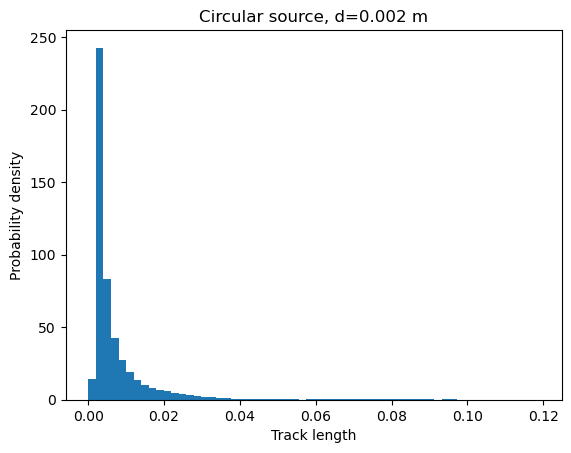

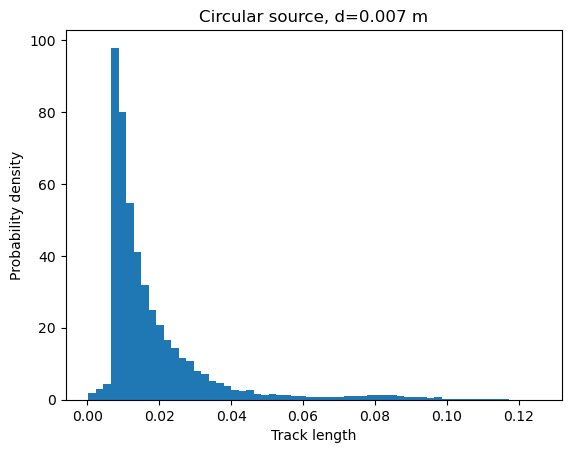

In [14]:
corner = (-0.05 + 0.02, -0.05 + 0.02)

for d in [0.002, 0.007]:
    lengths = run_simulation(
        N=20000,
        d=d,
        source_type="circle",
        R=0.02,
        center=corner
    )
    plot_histogram(lengths, f"Circular source, d={d} m")

#### Οπτικοποίηση για λίγες ευθείες:

i) Σημειακή πηγή:

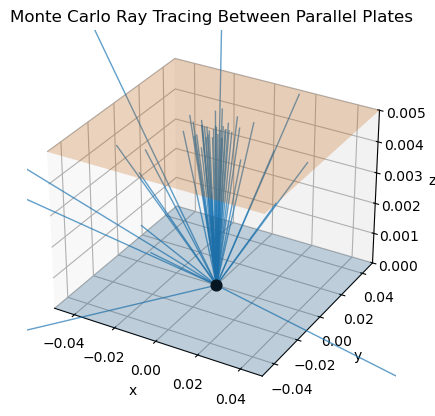

In [15]:
N = 200

dx, dy, dz = sample_isotropic_hemisphere(N)
x0, y0 = sample_point_source(N)

plot_rays(x0, y0, dx, dy, dz, d=0.005, plate_size=0.10)

ii) Κυκλική πηγή:

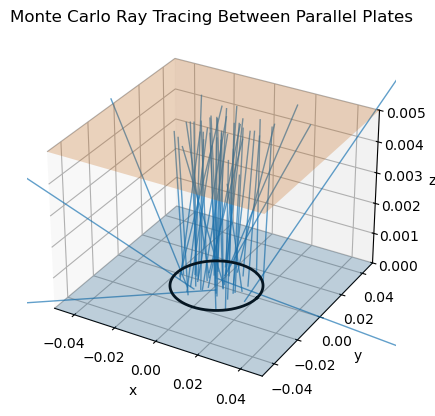

In [16]:
N = 100

dx, dy, dz = sample_isotropic_hemisphere(N)
x0, y0 = sample_circular_source_gaussian(N, R=0.02)

plot_rays(x0, y0, dx, dy, dz, d=0.005, plate_size=0.10, source_type="circle")